In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import timedelta

In [2]:
df = pd.read_parquet('../data/cleaned/amazon_sales_clean.parquet')

df['date'] = pd.to_datetime(df['date'])

print(f"Период: {df['date'].min().date()} — {df['date'].max().date()}")
print(f"Всего строк: {len(df)}")
print(f"Уникальных SKU: {df['sku'].nunique()}")

Период: 2022-03-31 — 2022-06-29
Всего строк: 116041
Уникальных SKU: 7132


In [3]:
df['CustomerID'] = (
    df['ship_city'].fillna('Unknown').str.strip().str.lower() + "_" +
    df['ship_state'].fillna('Unknown').str.strip().str.lower() + "_" +
    df['ship_postal_code'].fillna(0).astype(int).astype(str)
)

print(f"Уникальных клиентов (прокси): {df['CustomerID'].nunique()}")

Уникальных клиентов (прокси): 13821


In [4]:
snapshot_date = df['date'].max() + timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('date', 'nunique'),           
    Monetary=('amount', 'sum'),
    Total_Items=('qty', 'sum'),
    Num_Orders=('sku', 'nunique'),
    Avg_Order_Value=('amount', 'mean')
).reset_index()

In [5]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [6]:
def rfm_segment(x):
    if x['RFM_Total'] >= 13: return 'Champions'
    elif x['RFM_Total'] >= 10: return 'Loyal Customers'
    elif x['R_Score'] >= 4 and x['M_Score'] >= 4: return 'Promising'
    elif x['R_Score'] <= 2 and x['F_Score'] <= 2: return 'Lost'
    elif x['R_Score'] <= 2: return 'At Risk'
    elif x['F_Score'] <= 2: return 'Hibernating'
    else: return 'Need Attention'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

In [7]:
summary = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Pct_Customers=('CustomerID', lambda x: round(100 * len(x) / len(rfm), 2)),
    Total_Revenue=('Monetary', 'sum'),
    Pct_Revenue=('Monetary', lambda x: round(100 * x.sum() / rfm['Monetary'].sum(), 2)),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Order_Value=('Avg_Order_Value', 'mean')
).round(2).sort_values('Pct_Revenue', ascending=False)

display(summary)

,Customers,Pct_Customers,Total_Revenue,Pct_Revenue,Avg_Recency,Avg_Frequency,Avg_Order_Value
Segment,,,,,,,
Champions,3240,23.44,62835235.0,83.34,7.39,18.08,658.41
Loyal Customers,2677,19.37,6149903.0,8.16,23.68,2.99,684.99
Lost,3364,24.34,2391223.0,3.17,68.13,1.00,645.54
At Risk,1729,12.51,1945665.0,2.58,64.38,1.62,620.02
Hibernating,2088,15.11,1480488.0,1.96,21.94,1.00,662.48
Need Attention,719,5.20,589873.0,0.78,25.73,1.44,566.45
Promising,4,0.03,7484.0,0.01,14.50,1.00,605.19


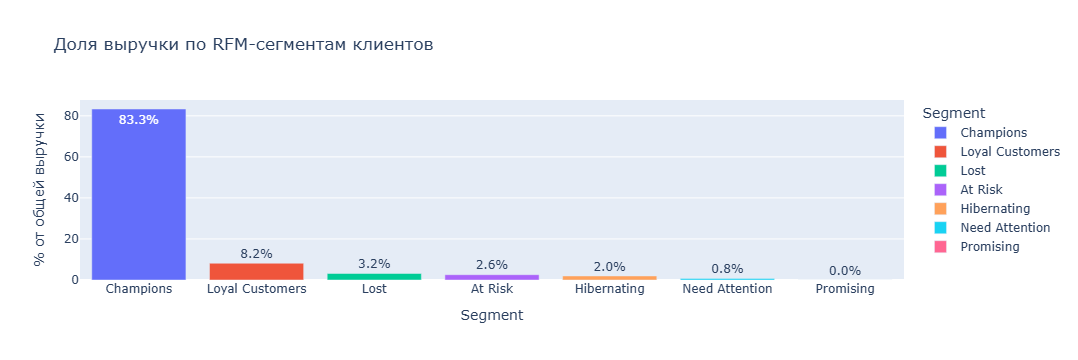

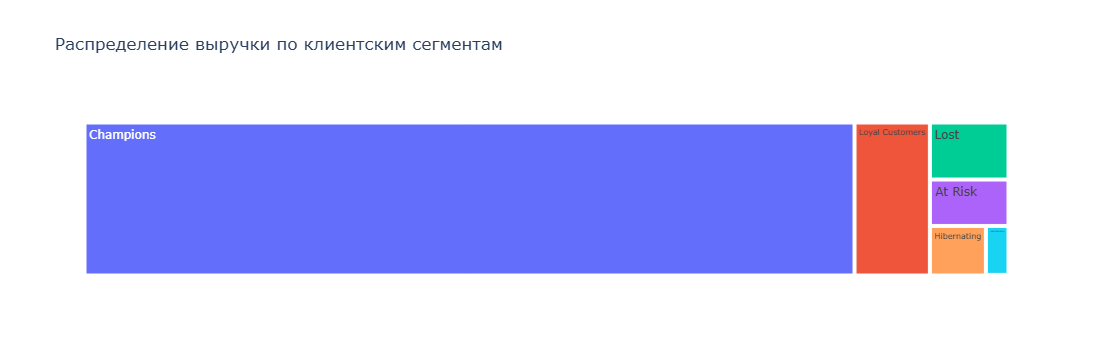

In [8]:
fig = px.bar(summary.reset_index(), 
             x='Segment', y='Pct_Revenue', color='Segment',
             title='Доля выручки по RFM-сегментам клиентов',
             labels={'Pct_Revenue': '% от общей выручки'},
             text='Pct_Revenue')
fig.update_traces(texttemplate='%{text:.1f}%')
fig.show()

fig2 = px.treemap(summary.reset_index(), path=['Segment'], values='Total_Revenue',
                  title='Распределение выручки по клиентским сегментам')
fig2.show()

In [9]:
rfm.to_parquet('../data/features/rfm_segments.parquet', index=False)
summary.to_csv('../data/features/rfm_summary.csv')

## Выводы по RFM-анализу

### Основные результаты сегментации

- **Champions** — самый ценный сегмент: составляет **23,4%** клиентов, но приносит **83,3%** компании.
- **Loyal Customers** — второй по важности сегмент: **19,4%** клиентов и **8,2%** выручки.
- Вместе **Champions и Loyal Customers** (всего **42,8%** клиентской базы) генерируют **91,5%** всей выручки.

- Остальные **57,2%** клиентов распределены по низкоценным сегментам:
  - **Lost** — 24,34% клиентов → всего 3,2% выручки
  - **At Risk** — 12,51% клиентов → 2,6% выручки
  - **Hibernating** — 15,11% клиентов → 2,0% выручки
  - **Need Attention** — 5,20% клиентов → 0,8% выручки
  - **Promising** — 0,03% клиентов → 0% выручки

### Ключевые инсайты

1. **Высокая концентрация выручки** — бизнес сильно зависит от менее чем 43% клиентов.
2. **Большой неэффективный хвост** — более 57% клиентской базы приносит менее 9% выручки.
3. **Сегмент Lost** является самым крупным по численности, что говорит о низком удержании клиентов после первых покупок.
4. **Практически отсутствует переходный слой** (сегмент Promising почти пустой) — очень мало клиентов, которые постепенно растут в лояльные покупатели.

### Ограничения анализа  
- Анализ проведён на данных за относительно короткий период — всего 4 месяца. В связи с этим:  
  - Метрика Recency имеет ограниченный диапазон (максимум ~120 дней), что снижает точность разделения клиентов.  
  - Метрика Frequency также ограничена — за 4 месяца сложно проявить высокую частоту покупок.  
  - Сегменты, сильно зависящие от давности и частоты (At Risk, Hibernating, Lost, Promising), следует интерпретировать с осторожностью.  


- Наиболее надёжными в текущих условиях являются сегменты Champions и Loyal Customers.  

### Бизнес-рекомендации

**Приоритет №1 — Удержание и развитие лояльных клиентов**
- Разработать программу лояльности специально для сегментов **Champions** и **Loyal Customers** (персональные скидки, повышенный кэшбек, ранний доступ к новинкам, эксклюзивные предложения).
- Ввести систему триггерных коммуникаций для повышения частоты покупок в этих сегментах.

**Приоритет №2 — Реактивация**
- Запустить targeted-кампании по реактивации сегментов **At Risk** и **Hibernating** с использованием персональных промокодов и специальных условий.
- Для сегмента **Lost** применять низкозатратные механики с высокой окупаемостью.

**Приоритет №3 — Оптимизация затрат**
- Сократить маркетинговые расходы на сегменты **Need Attention**, **Lost** и **Promising**.
- Перераспределить бюджет в пользу удержания и развития существующих высокоценных клиентов.

### Общий вывод

RFM-анализ показал ярко выраженную зависимость бизнеса от небольшой группы лояльных клиентов. Основной потенциал роста лежит не в привлечении новых пользователей, а в повышении Lifetime Value текущих Champions и Loyal Customers, а также в эффективной реактивации «спящих» сегментов.